## 1. Import Required Libraries

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2. Load the Dataset

In [31]:
# Load iris dataset
iris = load_iris()

# Create a DataFrame for easier manipulation
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df.to_csv('../data/temp/iris_dataset.csv', index=False)
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print(f"Dataset shape: {df.shape}")
print(f"\nFeatures: {iris.feature_names}")
print(f"\nTarget classes: {iris.target_names}")
df.head()

Dataset shape: (150, 6)

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target classes: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 3. Exploratory Data Analysis (EDA)

In [32]:
# Basic statistics
print("Dataset Statistics:")
print(df.describe())

print("\nClass Distribution:")
print(df['species_name'].value_counts())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)     species  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  

Class Distribution:
species_name
setosa        50
v

## 4. Data Visualization

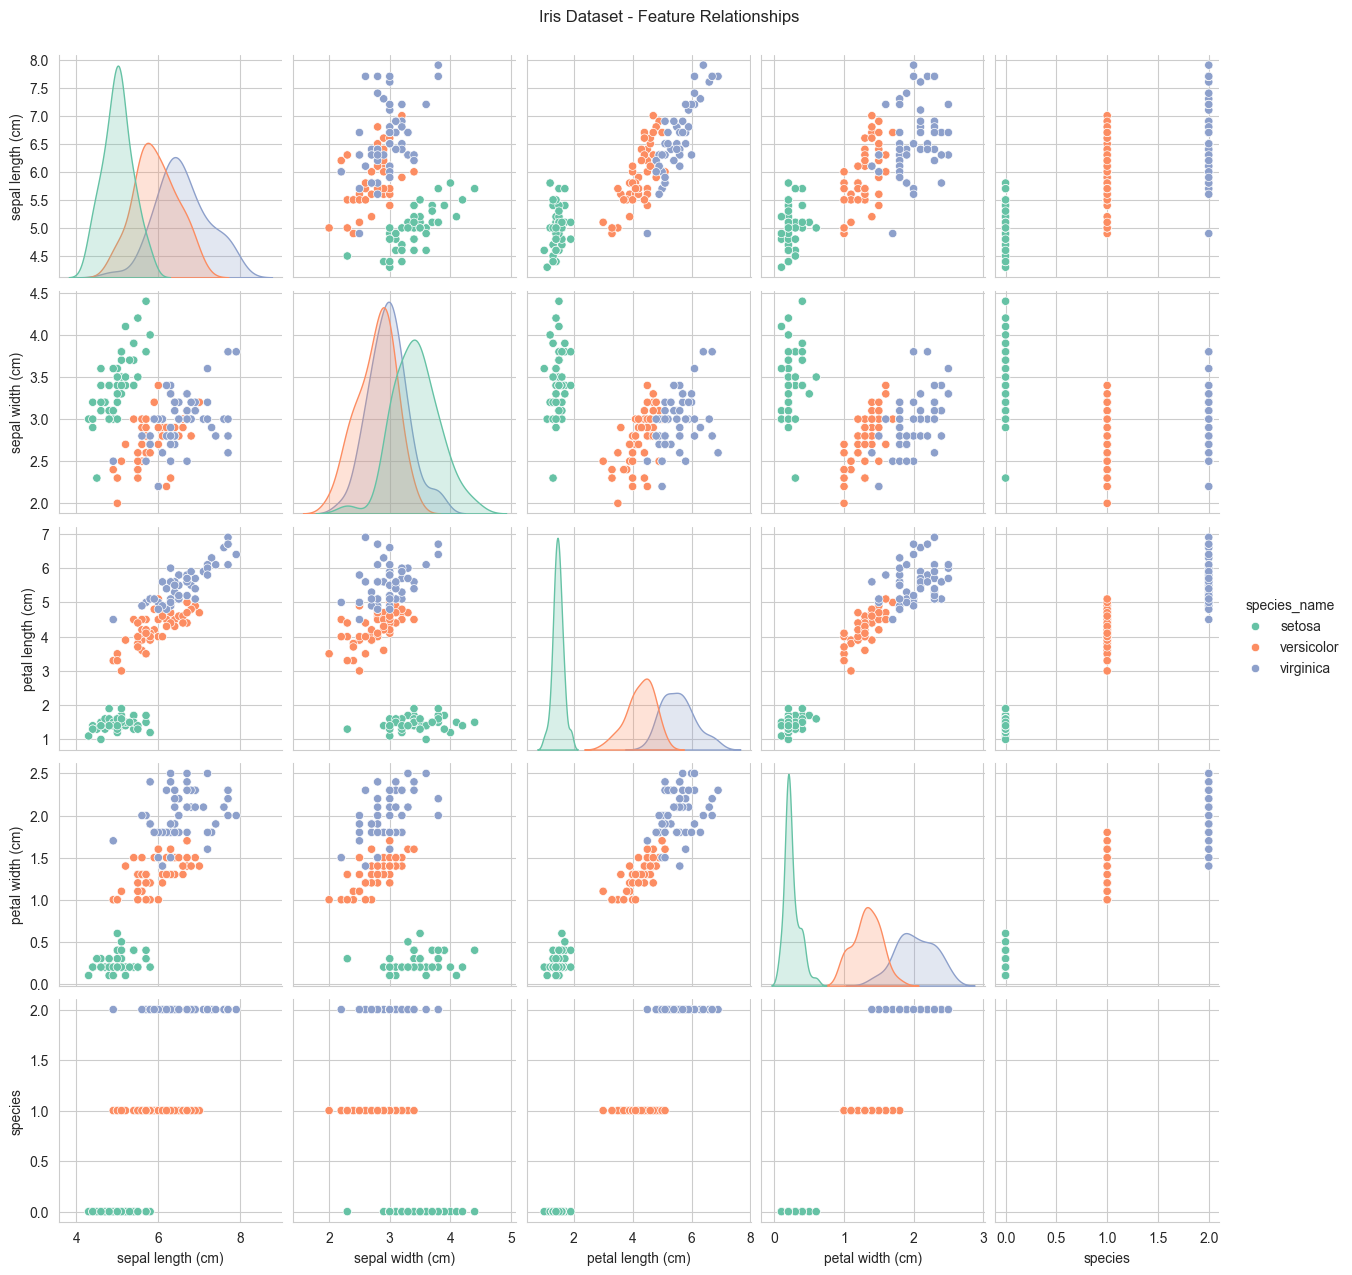

In [33]:
# Pairplot to visualize relationships between features
sns.pairplot(df, hue='species_name', palette='Set2')
plt.suptitle('Iris Dataset - Feature Relationships', y=1.02)
plt.show()

C:\Users\203715\AppData\Local\Temp\ipykernel_23668\1853396861.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species_name', y=col, palette='Set2', ax=ax)
C:\Users\203715\AppData\Local\Temp\ipykernel_23668\1853396861.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species_name', y=col, palette='Set2', ax=ax)
C:\Users\203715\AppData\Local\Temp\ipykernel_23668\1853396861.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species_name', y=col, palette='Set2', ax=ax)
C:\Users\203715\AppData\Local\Temp

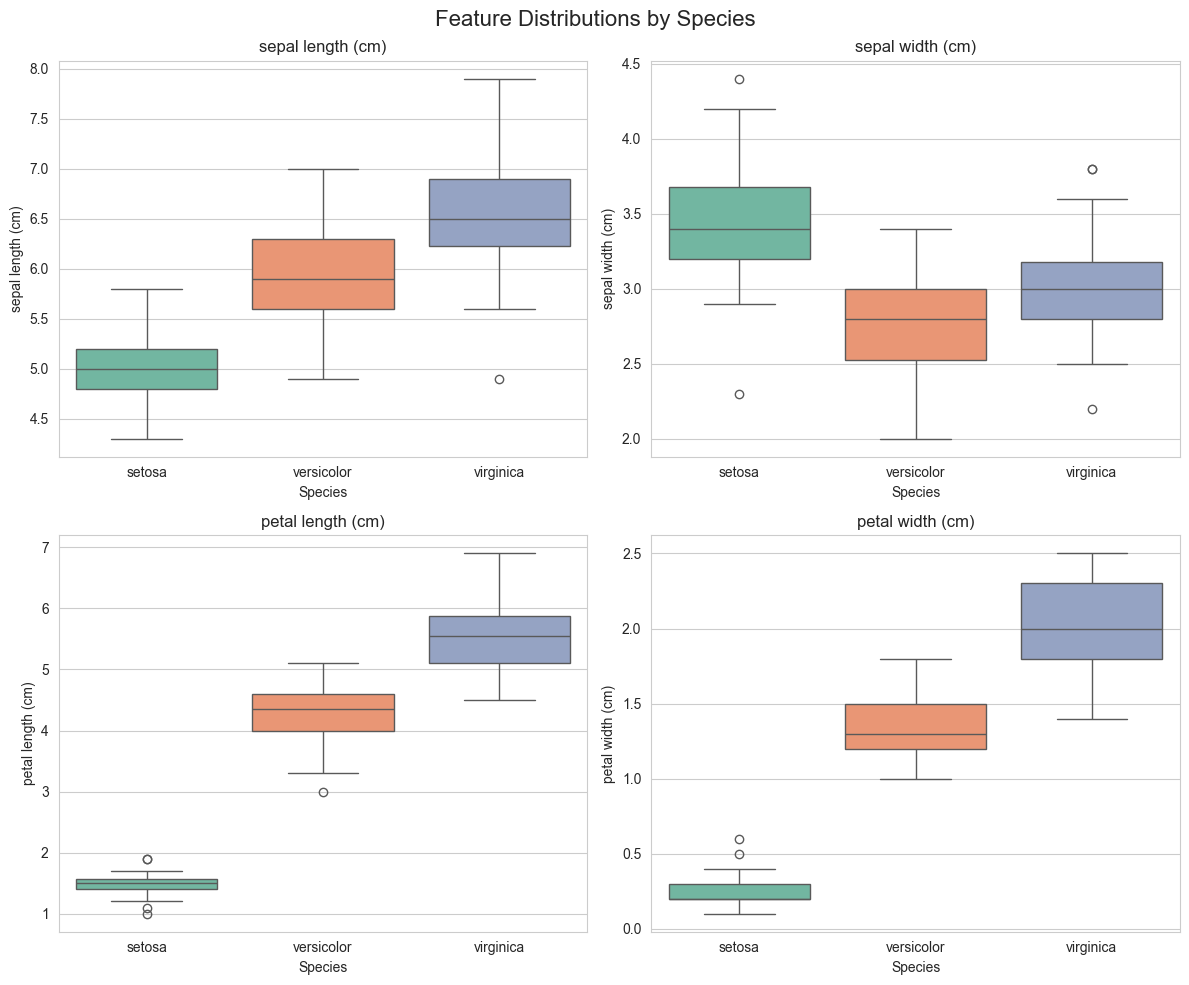

In [12]:
# Box plots for each feature
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Feature Distributions by Species', fontsize=16)

for idx, col in enumerate(iris.feature_names):
    ax = axes[idx // 2, idx % 2]
    sns.boxplot(data=df, x='species_name', y=col, palette='Set2', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('Species')

plt.tight_layout()
plt.show()

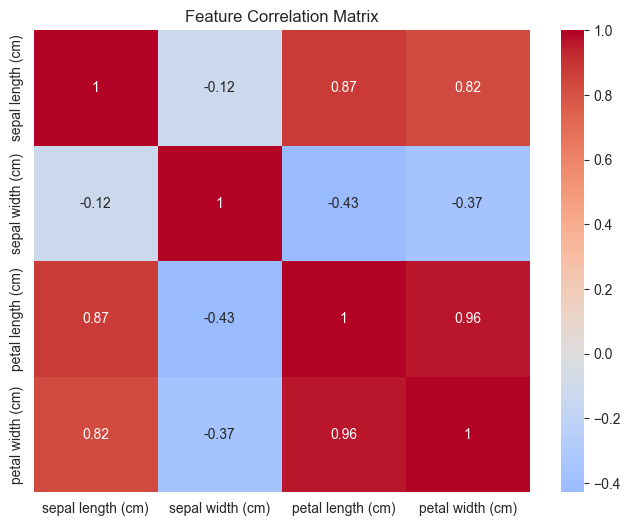

In [13]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
correlation = df[iris.feature_names].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

## 5. Prepare Data for Training

In [14]:
# Separate features and target
X = iris.data
y = iris.target

# Split into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# Feature scaling (standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✅ Data prepared and scaled!")

Training set size: 120 samples
Testing set size: 30 samples

✅ Data prepared and scaled!


## 6. Train the Model

We'll use K-Nearest Neighbors (KNN) classifier - a simple yet effective algorithm.

In [41]:
# Create and train KNN classifier
knn = KNeighborsClassifier(n_neighbors=13)
knn.fit(X_train_scaled, y_train)

print("✅ Model trained successfully!")

✅ Model trained successfully!


## 7. Make Predictions

In [42]:
# Predict on test set
y_pred = knn.predict(X_test_scaled)

# Show first few predictions
results_df = pd.DataFrame({
    'Actual': [iris.target_names[y] for y in y_test[:10]],
    'Predicted': [iris.target_names[y] for y in y_pred[:10]]
})
print("First 10 predictions:")
print(results_df)

First 10 predictions:
       Actual   Predicted
0      setosa      setosa
1   virginica   virginica
2  versicolor  versicolor
3  versicolor  versicolor
4      setosa      setosa
5  versicolor  versicolor
6      setosa      setosa
7      setosa      setosa
8   virginica   virginica
9  versicolor  versicolor


## 8. Evaluate Model Performance

In [43]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2%}\n")

# Detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Model Accuracy: 96.67%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



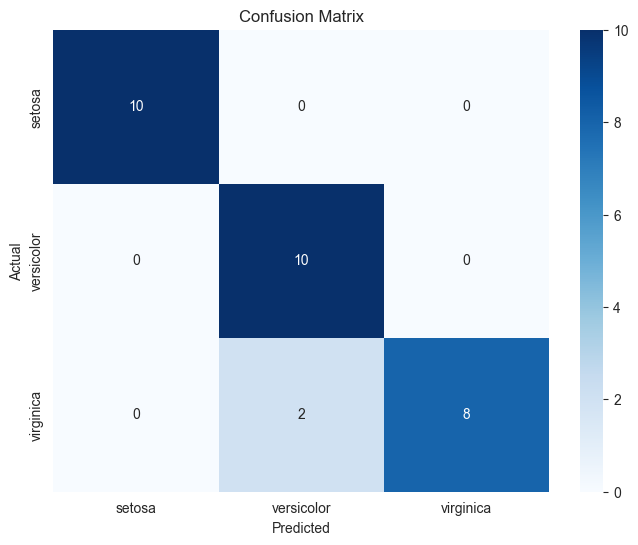

In [18]:
# Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=iris.target_names, 
            yticklabels=iris.target_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## 9. Test with Custom Input

Try predicting the species of a flower with custom measurements!

In [23]:
# Example: Custom flower measurements
custom_flower = np.array([[5.1, 3.5, 1.4, 0.2]])  # Typical setosa measurements

# Scale the input
custom_flower_scaled = scaler.transform(custom_flower)

# Predict
prediction = knn.predict(custom_flower_scaled)
prediction_proba = knn.predict_proba(custom_flower_scaled)

print(f"Input: Sepal Length={custom_flower[0][0]}, Sepal Width={custom_flower[0][1]}, "
      f"Petal Length={custom_flower[0][2]}, Petal Width={custom_flower[0][3]}")
print(f"\nPredicted Species: {iris.target_names[prediction[0]].upper()}")
print(f"\nPrediction Probabilities:")
for i, prob in enumerate(prediction_proba[0]):
    print(f"  {iris.target_names[i]}: {prob:.2%}")

Input: Sepal Length=0.9, Sepal Width=0.9, Petal Length=9.9, Petal Width=0.9

Predicted Species: VERSICOLOR

Prediction Probabilities:
  setosa: 0.00%
  versicolor: 66.67%
  virginica: 33.33%


## 10. Experiment: Try Different K Values

k=1:
Accuracy: 96.67%
score: Train=100.00%, Test=96.67%
Average: 96.00%, Std: 5.33%
k=2:
Accuracy: 93.33%
score: Train=96.67%, Test=93.33%
Average: 95.33%, Std: 5.21%
k=3:
Accuracy: 93.33%
score: Train=95.83%, Test=93.33%
Average: 96.67%, Std: 4.47%
k=4:
Accuracy: 93.33%
score: Train=95.83%, Test=93.33%
Average: 96.67%, Std: 4.47%
k=5:
Accuracy: 93.33%
score: Train=97.50%, Test=93.33%
Average: 96.67%, Std: 4.47%
k=6:
Accuracy: 93.33%
score: Train=95.83%, Test=93.33%
Average: 96.67%, Std: 4.47%
k=7:
Accuracy: 96.67%
score: Train=97.50%, Test=96.67%
Average: 96.67%, Std: 4.47%
k=8:
Accuracy: 93.33%
score: Train=95.83%, Test=93.33%
Average: 96.67%, Std: 4.47%
k=9:
Accuracy: 96.67%
score: Train=95.83%, Test=96.67%
Average: 97.33%, Std: 3.27%
k=10:
Accuracy: 96.67%
score: Train=95.83%, Test=96.67%
Average: 96.67%, Std: 4.47%
k=11:
Accuracy: 96.67%
score: Train=95.83%, Test=96.67%
Average: 96.67%, Std: 4.47%
k=12:
Accuracy: 96.67%
score: Train=95.83%, Test=96.67%
Average: 97.33%, Std: 3.27%


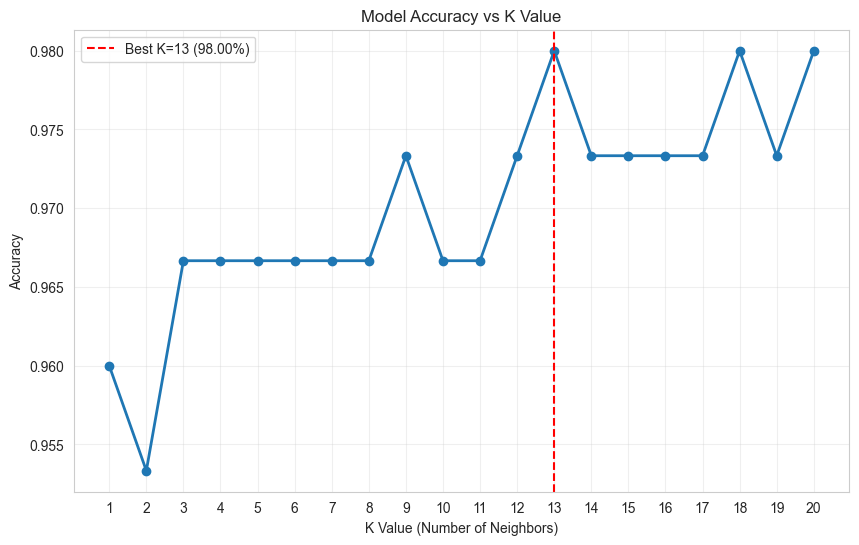

Best K value: 13 with accuracy: 98.00%


In [29]:
from sklearn.model_selection import cross_val_score

# Test different K values
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    
    print(f"k={k}:")
    
    y_pred_temp = knn_temp.predict(X_test_scaled)
    print(f"Accuracy: {accuracy_score(y_test, y_pred_temp):.2%}")
    # accuracies.append(accuracy_score(y_test, y_pred_temp))
    
    train_acc = knn_temp.score(X_train_scaled, y_train)
    test_acc = knn_temp.score(X_test_scaled, y_test)
    print(f"score: Train={train_acc:.2%}, Test={test_acc:.2%}")
    # accuracies.append(test_acc)
    
    scores = cross_val_score(knn_temp, X, y, cv=10)  # 10 different splits
    print(f"Average: {scores.mean():.2%}, Std: {scores.std():.2%}")
    accuracies.append(scores.mean())

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linewidth=2)
plt.xlabel('K Value (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.title('Model Accuracy vs K Value')
plt.grid(True, alpha=0.3)
plt.xticks(k_values)

best_k = k_values[np.argmax(accuracies)]
best_accuracy = max(accuracies)
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K={best_k} ({best_accuracy:.2%})')
plt.legend()
plt.show()

print(f"Best K value: {best_k} with accuracy: {best_accuracy:.2%}")

## Summary

**What we learned:**
1. ✅ How to load and explore a dataset
2. ✅ Visualizing data patterns and relationships
3. ✅ Preparing data for machine learning
4. ✅ Training a classification model
5. ✅ Evaluating model performance
6. ✅ Making predictions with new data
7. ✅ Experimenting with hyperparameters

**Next Steps:**
- Try other algorithms (Decision Trees, SVM, Random Forest)
- Work with a more complex dataset
- Learn about feature engineering
- Explore deep learning with neural networks